# Phase 3: Deployment & Explainable AI
## AI-Powered Chatbot for Research Paper Analysis

**Project:** AI-Powered Chatbot for Research Paper Analysis  
**Dataset:** ArXiv Metadata (Phase 2) · ML Models (Phase 3)  
**Team:** Anisha Gehlot · Moulya Reddygari Bhupal · Sreyesh Varma Konduru · Karthikeya Myneedu

---

### Notebook Structure

| Section | Track |
|---------|-------|
| 1. Setup & Model Rebuild |
| 2. Production Architecture | Deployment |
| 3. Gradio API Interface | Deployment |
| 4. Monitoring & Maintenance | Deployment |
| 5. SHAP Global Explanations | XAI |
| 6. SHAP Local Explanations | XAI |
| 7. Bias & Fairness Audit | XAI |
| 8. Perfect Score Transparency | XAI |
| 9. Summary & Roles | Both |

---
## 1. Setup — Install, Import & Rebuild Models from Phase 3


In [1]:
# ── Install all required libraries ────────────────────────────────────────────
!pip install arxiv shap gradio scikit-learn matplotlib seaborn scipy --quiet

import arxiv, re, warnings, joblib, json
import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.patches   as mpatches
import matplotlib.gridspec  as gridspec
import seaborn as sns
import shap
from scipy import stats
from datetime import datetime

from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, KFold,
    cross_val_score, cross_validate
)
from sklearn.neighbors    import KNeighborsClassifier
from sklearn.ensemble     import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.dummy        import DummyClassifier, DummyRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    mean_squared_error, mean_absolute_error, r2_score
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')
print('All libraries loaded!')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.8 MB/s eta 0:00:00
All libraries loaded!


In [2]:
# ── Rebuild dataset (identical to Phase 2 & 3) ────────────────────────────────
QUERIES = [
    ('retrieval augmented generation',               'cs.CL'),
    ('large language model hallucination',           'cs.CL'),
    ('scientific document understanding NLP',        'cs.CL'),
    ('question answering document grounding',        'cs.AI'),
    ('semantic search embeddings',                   'cs.IR'),
    ('healthcare AI clinical NLP',                   'cs.LG'),
    ('RAG retrieval augmented generation evaluation','cs.LG'),
    ('PDF document parsing information extraction',  'cs.CV'),
]

all_records = []
for query_text, category in QUERIES:
    full_query = f'({query_text}) AND cat:{category}'
    print(f'🔍 Fetching: {query_text[:48]}...')
    try:
        search = arxiv.Search(
            query=full_query, max_results=75,
            sort_by=arxiv.SortCriterion.SubmittedDate,
            sort_order=arxiv.SortOrder.Descending
        )
        for paper in search.results():
            all_records.append({
                'arxiv_id'        : paper.entry_id.split('/')[-1],
                'title'           : paper.title,
                'abstract'        : paper.summary,
                'num_authors'     : len(paper.authors),
                'categories'      : paper.categories,
                'primary_category': paper.primary_category,
                'published'       : paper.published,
                'updated'         : paper.updated,
                'query_topic'     : query_text,
                'query_category'  : category,
            })
    except Exception as e:
        print(f' {e}')

df_raw = pd.DataFrame(all_records).drop_duplicates(subset='arxiv_id').copy()
print(f'\nUnique papers: {len(df_raw)}')

🔍 Fetching: retrieval augmented generation...
🔍 Fetching: large language model hallucination...
🔍 Fetching: scientific document understanding NLP...
🔍 Fetching: question answering document grounding...
🔍 Fetching: semantic search embeddings...
🔍 Fetching: healthcare AI clinical NLP...
🔍 Fetching: RAG retrieval augmented generation evaluation...
🔍 Fetching: PDF document parsing information extraction...

Unique papers: 464


In [3]:
# ── Feature engineering (identical to Phase 3) ────────────────────────────────
df = df_raw.copy()
df['published']      = pd.to_datetime(df['published'], utc=True)
df['updated']        = pd.to_datetime(df['updated'],   utc=True)
df['days_to_update'] = (df['updated'] - df['published']).dt.days
df['pub_month']      = df['published'].dt.month
df['title_len']      = df['title'].str.split().str.len()
df['abstract_len']   = df['abstract'].str.split().str.len()
df['abstract_chars'] = df['abstract'].str.len()
df['num_categories'] = df['categories'].apply(len)

kw_patterns = {
    'kw_rag'        : r'retrieval.augmented',
    'kw_hallucin'   : r'hallucin',
    'kw_embedding'  : r'embed',
    'kw_citation'   : r'citat',
    'kw_transformer': r'transformer',
    'kw_evaluation' : r'evaluat',
    'kw_grounding'  : r'ground',
    'kw_qa'         : r'question.answer',
    'kw_pdf'        : r'\bpdf\b',
    'kw_llm'        : r'\bllm\b|large language model',
}
for col, pat in kw_patterns.items():
    df[col] = df['abstract'].apply(
        lambda x: int(bool(re.search(pat, x, re.IGNORECASE)))
    )

df['primary_cat_clean'] = df['primary_category'].str.split('.').str[0]
le_cat  = LabelEncoder()
le_qcat = LabelEncoder()
df['cat_encoded']  = le_cat.fit_transform(df['primary_cat_clean'])
df['qcat_encoded'] = le_qcat.fit_transform(df['query_category'])

df['is_rag_relevant'] = (
    (df['kw_rag'] == 1) | (df['kw_hallucin'] == 1) |
    (df['kw_grounding'] == 1) | (df['kw_qa'] == 1)
).astype(int)

NUMERIC_FEATS = ['num_authors','title_len','num_categories',
                 'days_to_update','pub_month','abstract_chars']
KEYWORD_FEATS = list(kw_patterns.keys())
CAT_FEATS     = ['cat_encoded','qcat_encoded']
FEATS_A       = NUMERIC_FEATS + KEYWORD_FEATS + CAT_FEATS
FEATS_B       = ['num_authors','title_len','num_categories','days_to_update',
                 'pub_month','cat_encoded','qcat_encoded','is_rag_relevant']
FEAT_LABELS   = {
    'num_authors'   :'# Authors',   'title_len'     :'Title Length',
    'num_categories':'# Categories','days_to_update':'Days to Update',
    'pub_month'     :'Pub. Month',  'abstract_chars':'Abstract Chars',
    'kw_rag'        :'KW: RAG',     'kw_hallucin'   :'KW: Hallucination',
    'kw_embedding'  :'KW: Embedding','kw_citation'  :'KW: Citation',
    'kw_transformer':'KW: Transformer','kw_evaluation':'KW: Evaluation',
    'kw_grounding'  :'KW: Grounding','kw_qa'        :'KW: Q&A',
    'kw_pdf'        :'KW: PDF',     'kw_llm'        :'KW: LLM',
    'cat_encoded'   :'Category',    'qcat_encoded'  :'Query Category',
    'is_rag_relevant':'RAG Relevant',
}

print(f'Features ready. Dataset: {df.shape}')
print(f'   Relevant papers: {df["is_rag_relevant"].sum()} / {len(df)}')

Features ready. Dataset: (464, 30)
   Relevant papers: 137 / 464


In [4]:
# ── Rebuild all Phase 3 models ─────────────────────────────────────────────────
X_a = df[FEATS_A].values
y_a = df['is_rag_relevant'].values
X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(
    X_a, y_a, test_size=0.20, random_state=42, stratify=y_a
)

X_b = df[FEATS_B].values
y_b = df['abstract_len'].values
X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(
    X_b, y_b, test_size=0.20, random_state=42
)

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf       = KFold(n_splits=5, shuffle=True, random_state=42)

# ── Logistic Regression (best classifier from Phase 3) ────────────────────────
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(C=1, penalty='l1', solver='liblinear',
                                  random_state=42, max_iter=1000,
                                  class_weight='balanced'))
])
lr_pipe.fit(X_a_train, y_a_train)

# ── Random Forest Classifier ──────────────────────────────────────────────────
rf_clf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf',     RandomForestClassifier(n_estimators=50, max_depth=None,
                                      min_samples_split=10, random_state=42,
                                      class_weight='balanced'))
])
rf_clf_pipe.fit(X_a_train, y_a_train)

# ── Ridge Regressor (best from Phase 3) ───────────────────────────────────────
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=100))
])
ridge_pipe.fit(X_b_train, y_b_train)

# ── Random Forest Regressor ───────────────────────────────────────────────────
rf_reg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf',     RandomForestRegressor(n_estimators=50, max_depth=5,
                                     min_samples_split=10, random_state=42))
])
rf_reg_pipe.fit(X_b_train, y_b_train)

# Pre-scale test data for SHAP
scaler_a = lr_pipe.named_steps['scaler']
X_a_test_scaled  = scaler_a.transform(X_a_test)
X_a_train_scaled = scaler_a.transform(X_a_train)

print('All Phase 3 models rebuilt!')
y_pred_lr = lr_pipe.predict(X_a_test)
print(f'   LR Test Accuracy : {accuracy_score(y_a_test, y_pred_lr):.4f}')
print(f'   LR Test F1       : {f1_score(y_a_test, y_pred_lr):.4f}')

All Phase 3 models rebuilt!
   LR Test Accuracy : 1.0000
   LR Test F1       : 1.0000


---
## 2. Production Architecture

### 2.1 Real-Time vs Batch Decision

Our two models serve **different roles** in the chatbot pipeline:

| Model | Mode | Trigger | Latency Target |
|-------|------|---------|----------------|
| Logistic Regression Classifier (`is_rag_relevant`) | Real-time | Every new PDF upload or ArXiv fetch | < 50ms |
| Ridge Regressor (`abstract_len`) | At-index-time | During chunking step after PDF parsing | < 100ms |

The classifier runs before embedding — it gates whether a paper enters the vector store at all. This prevents irrelevant papers from polluting FAISS/ChromaDB and degrading retrieval precision.

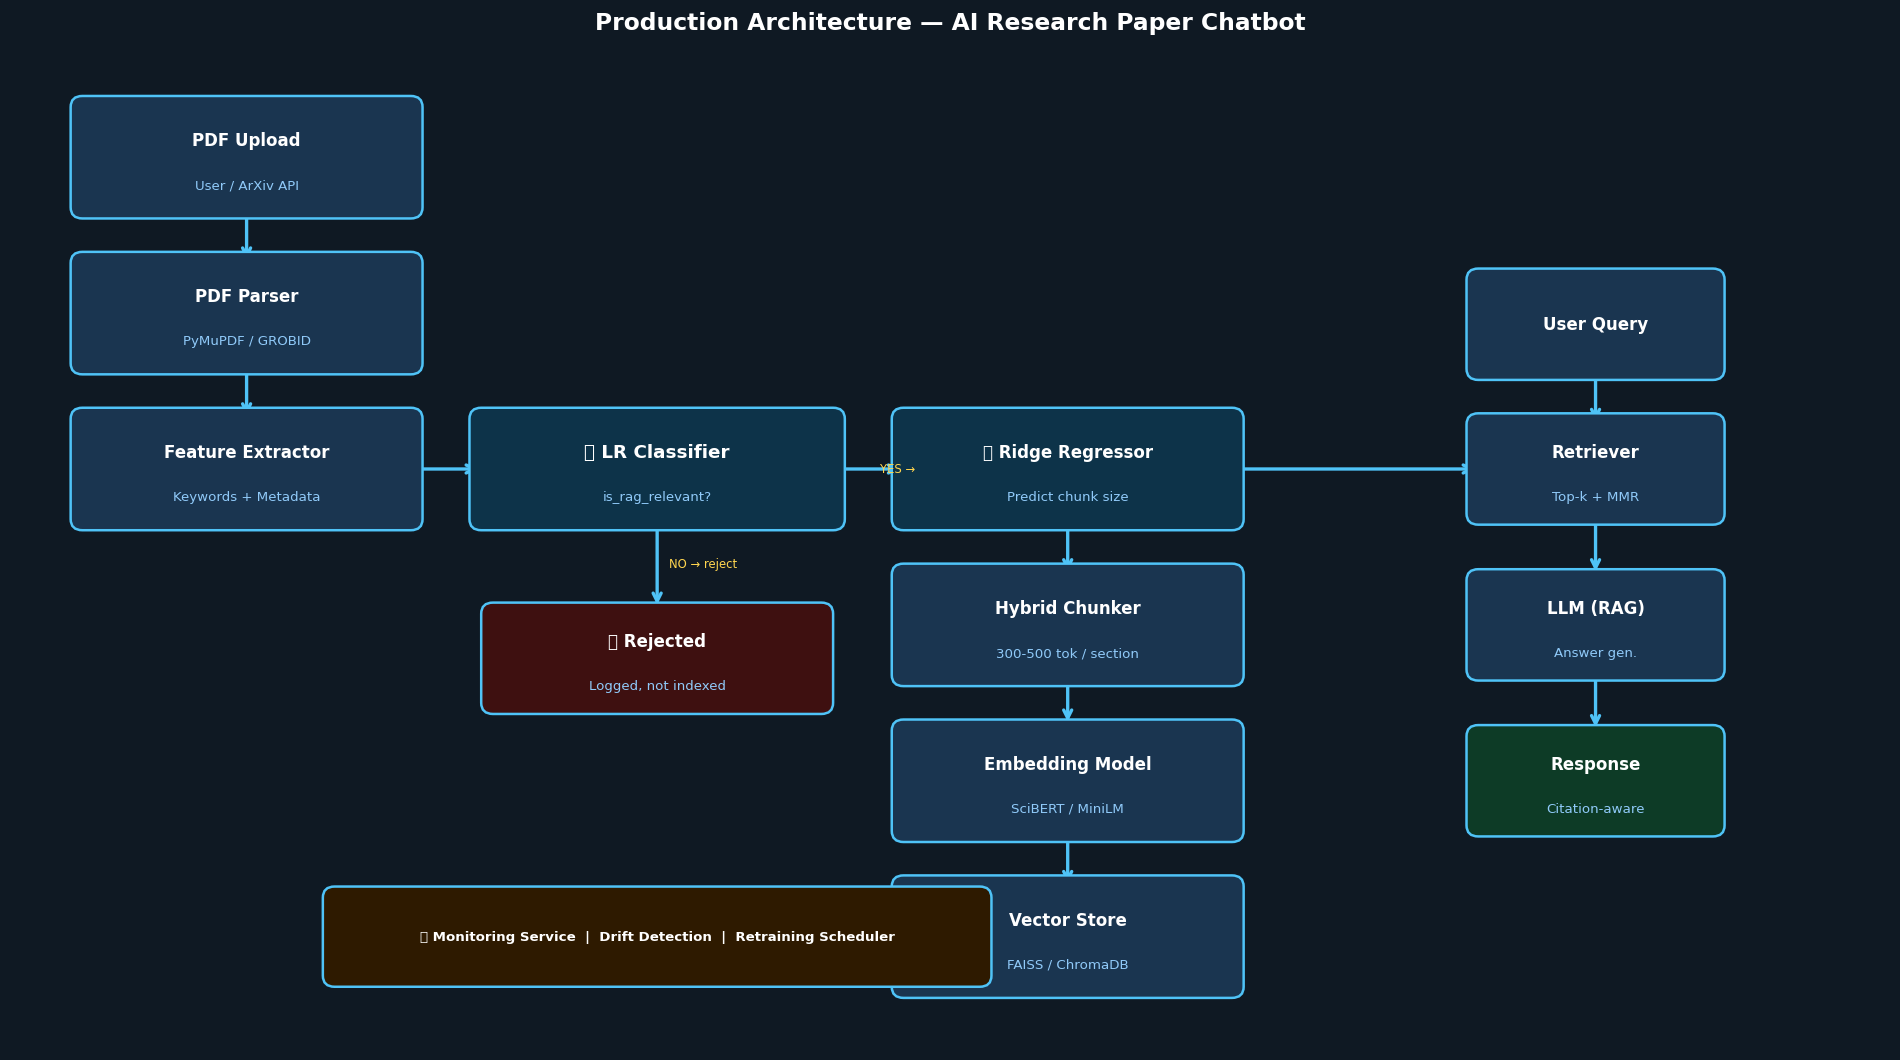

The LR classifier acts as a GATE before embedding — preventing irrelevant
   papers from entering the vector store and degrading retrieval quality.


In [5]:
# ── Production Architecture Diagram ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis('off')
ax.set_facecolor('#0F1923')
fig.patch.set_facecolor('#0F1923')

def box(ax, x, y, w, h, label, sublabel='', color='#1E3A5F', textcolor='white',
        fontsize=10, subfontsize=8):
    rect = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
        boxstyle='round,pad=0.1', linewidth=1.5,
        edgecolor='#4FC3F7', facecolor=color, zorder=3)
    ax.add_patch(rect)
    ax.text(x, y + (0.15 if sublabel else 0), label,
            ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color=textcolor, zorder=4)
    if sublabel:
        ax.text(x, y - 0.25, sublabel, ha='center', va='center',
                fontsize=subfontsize, color='#90CAF9', zorder=4)

def arrow(ax, x1, y1, x2, y2, label='', color='#4FC3F7'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle='->', color=color, lw=2), zorder=2)
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.1, my, label, fontsize=7, color='#FFD54F',
                ha='left', va='center', zorder=5)

# ── Nodes ─────────────────────────────────────────────────────────────────────
# Row 1: Input
box(ax, 2,   8,   2.8, 0.9, 'PDF Upload',       'User / ArXiv API',      '#1A3550')
box(ax, 2,   6.6, 2.8, 0.9, 'PDF Parser',       'PyMuPDF / GROBID',      '#1A3550')
box(ax, 2,   5.2, 2.8, 0.9, 'Feature Extractor','Keywords + Metadata',   '#1A3550')

# Row 2: Decision gate
box(ax, 5.5, 5.2, 3.0, 0.9, '🔍 LR Classifier', 'is_rag_relevant?',      '#0D3349', fontsize=11)

# Reject path
box(ax, 5.5, 3.5, 2.8, 0.8, '🚫 Rejected',      'Logged, not indexed',   '#3E1010')

# Accept path
box(ax, 9,   5.2, 2.8, 0.9, '📏 Ridge Regressor','Predict chunk size',    '#0D3349')
box(ax, 9,   3.8, 2.8, 0.9, 'Hybrid Chunker',   '300-500 tok / section', '#1A3550')
box(ax, 9,   2.4, 2.8, 0.9, 'Embedding Model',  'SciBERT / MiniLM',      '#1A3550')
box(ax, 9,   1.0, 2.8, 0.9, 'Vector Store',     'FAISS / ChromaDB',      '#1A3550')

# Query side
box(ax, 13.5, 6.5, 2.0, 0.8, 'User Query',   '',                         '#1A3550')
box(ax, 13.5, 5.2, 2.0, 0.8, 'Retriever',    'Top-k + MMR',              '#1A3550')
box(ax, 13.5, 3.8, 2.0, 0.8, 'LLM (RAG)',    'Answer gen.',              '#1A3550')
box(ax, 13.5, 2.4, 2.0, 0.8, 'Response',     'Citation-aware',           '#0D3B26')

# Monitoring
box(ax, 5.5, 1.0, 5.5, 0.7, '📊 Monitoring Service  |  Drift Detection  |  Retraining Scheduler',
    '', '#2E1A00', fontsize=8)

# ── Arrows ────────────────────────────────────────────────────────────────────
arrow(ax, 2,  7.55, 2,  7.05)                        # upload → parser
arrow(ax, 2,  6.15, 2,  5.65)                        # parser → features
arrow(ax, 3.4, 5.2, 4.0, 5.2)                        # features → classifier
arrow(ax, 5.5, 4.75, 5.5, 3.95, 'NO → reject')       # classifier → reject
arrow(ax, 7.0, 5.2, 7.6,  5.2, 'YES →')              # classifier → regressor
arrow(ax, 9,  4.75, 9,   4.25)                        # regressor → chunker
arrow(ax, 9,  3.35, 9,   2.9)                         # chunker → embedder
arrow(ax, 9,  1.95, 9,   1.45)                        # embedder → vector store
arrow(ax, 13.5, 6.1, 13.5, 5.6)                       # query → retriever
arrow(ax, 10.4, 5.2, 12.5, 5.2)                       # vector store ↔ retriever
arrow(ax, 13.5, 4.75, 13.5, 4.25)                     # retriever → LLM
arrow(ax, 13.5, 3.35, 13.5, 2.85)                     # LLM → response
arrow(ax, 9,   1.0, 7.75, 1.0, '')                    # vector → monitoring

ax.set_title('Production Architecture — AI Research Paper Chatbot',
             fontsize=14, fontweight='bold', color='white', pad=10)

plt.tight_layout()
plt.savefig('arch_diagram.png', bbox_inches='tight', dpi=150,
            facecolor='#0F1923')
plt.show()
print('The LR classifier acts as a GATE before embedding — preventing irrelevant')
print('   papers from entering the vector store and degrading retrieval quality.')

---
## 3. Gradio API Interface

This section builds a live, interactive API mockup using Gradio. A user pastes a paper title and abstract; the system returns:
- Relevance prediction (Relevant / Not Relevant)
- Confidence score
- Predicted abstract length (informs chunking)
- Feature breakdown - which keywords triggered the decision
- Recommended chunk size for the RAG pipeline

In [6]:
import gradio as gr

# ── Feature extraction helper (mirrors Phase 3 engineering) ───────────────────
def extract_features_from_text(title: str, abstract: str,
                                num_authors: int = 4,
                                primary_cat: str = 'cs.CL') -> dict:
    """Extract the 18 Task-A features from raw title + abstract text."""
    cat_clean = primary_cat.split('.')[0].lower()
    cat_map   = {'cs':0,'econ':1,'eess':2,'physics':3,'q-bio':4,'quant-ph':5,'stat':6}
    cat_enc   = cat_map.get(cat_clean, 0)

    kw_flags = {}
    for col, pat in kw_patterns.items():
        kw_flags[col] = int(bool(re.search(pat, abstract, re.IGNORECASE)))

    features = {
        'num_authors'   : num_authors,
        'title_len'     : len(title.split()),
        'num_categories': 2,          # default assumption
        'days_to_update': 0,
        'pub_month'     : datetime.now().month,
        'abstract_chars': len(abstract),
        **kw_flags,
        'cat_encoded'   : cat_enc,
        'qcat_encoded'  : 0,
    }
    return features

# ── Prediction function ────────────────────────────────────────────────────────
def predict_paper(title, abstract, num_authors, primary_category):
    if not title.strip() or not abstract.strip():
        return ('Please provide both title and abstract.', None, None, None)

    feats = extract_features_from_text(title, abstract,
                                       int(num_authors), primary_category)
    x_vec = np.array([[feats[f] for f in FEATS_A]])

    # ── Classification ────────────────────────────────────────────────────────
    proba     = lr_pipe.predict_proba(x_vec)[0, 1]
    label     = 'RAG Relevant' if proba >= 0.5 else 'Not Relevant ❌'
    confidence = f'{proba * 100:.1f}%'

    # ── Regression: predicted abstract length ─────────────────────────────────
    x_b  = np.array([[feats[f] for f in FEATS_B]])
    # FEATS_B needs is_rag_relevant; derive it
    rag_rel = int(proba >= 0.5)
    x_b_full = np.array([[feats['num_authors'], feats['title_len'],
                           feats['num_categories'], feats['days_to_update'],
                           feats['pub_month'], feats['cat_encoded'],
                           feats['qcat_encoded'], rag_rel]])
    pred_len  = int(ridge_pipe.predict(x_b_full)[0])

    # ── Chunk size recommendation ──────────────────────────────────────────────
    if pred_len < 150:
        chunk_rec = 'Short abstract → 300-token chunks, no overlap'
    elif pred_len <= 220:
        chunk_rec = 'Medium abstract → 400-token chunks, 50-token overlap (recommended)'
    else:
        chunk_rec = 'Long abstract → 500-token chunks, 100-token overlap'

    # ── Keyword triggers ──────────────────────────────────────────────────────
    triggered = [k.replace('kw_','').upper()
                 for k in kw_patterns if feats.get(k, 0) == 1]
    kw_str = ', '.join(triggered) if triggered else 'None detected'

    result_str = (
        f'**Prediction:** {label}\n'
        f'**Confidence:** {confidence}\n\n'
        f'**Keywords triggered:** {kw_str}\n\n'
        f'**Predicted abstract length:** {pred_len} words\n'
        f'**Chunking recommendation:** {chunk_rec}'
    )
    return result_str, f'{proba:.4f}', f'{pred_len} words', chunk_rec

# ── Sample papers for demo ────────────────────────────────────────────────────
SAMPLES = [
    [
        'Retrieval-Augmented Generation for Grounded Academic QA',
        'We propose a retrieval-augmented generation system for question answering '
        'over scientific documents. Our approach grounds responses in retrieved '
        'passages, reducing hallucination and improving citation accuracy. '
        'Experiments on PubMed and arXiv corpora demonstrate significant '
        'improvements in faithfulness scores over baseline LLMs.',
        4, 'cs.CL'
    ],
    [
        'Optimal Transport for Distribution Matching in Generative Models',
        'We study the application of optimal transport theory to distribution '
        'matching in variational autoencoders. Our theoretical analysis establishes '
        'convergence bounds under mild assumptions. Numerical experiments on image '
        'synthesis tasks confirm the practical utility of the proposed framework.',
        3, 'stat'
    ],
]

# ── Build Gradio Interface ─────────────────────────────────────────────────────
with gr.Blocks(title='Research Paper RAG Relevance API',
               theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 📚 Research Paper RAG Relevance Classifier
    ### AI-Powered Chatbot — Phase 4 API Mockup
    Paste a paper's title and abstract to check if it should enter your RAG pipeline.
    The system predicts relevance, confidence, and optimal chunking strategy.
    """)

    with gr.Row():
        with gr.Column(scale=2):
            title_input   = gr.Textbox(label='Paper Title', lines=2,
                                       placeholder='Enter the paper title...')
            abstract_input = gr.Textbox(label='Abstract', lines=6,
                                        placeholder='Paste the abstract here...')
            with gr.Row():
                authors_input = gr.Number(label='Number of Authors', value=4,
                                          minimum=1, maximum=100)
                cat_input     = gr.Dropdown(
                    label='Primary ArXiv Category',
                    choices=['cs.CL','cs.AI','cs.LG','cs.IR','cs.CV',
                             'eess.IV','q-bio.QM','stat.ML'],
                    value='cs.CL'
                )
            predict_btn = gr.Button('🔍 Classify Paper', variant='primary')

        with gr.Column(scale=2):
            result_md   = gr.Markdown(label='Result')
            conf_out    = gr.Textbox(label='Raw Probability Score', interactive=False)
            len_out     = gr.Textbox(label='Predicted Abstract Length', interactive=False)
            chunk_out   = gr.Textbox(label='Chunking Strategy', interactive=False)

    predict_btn.click(
        fn=predict_paper,
        inputs=[title_input, abstract_input, authors_input, cat_input],
        outputs=[result_md, conf_out, len_out, chunk_out]
    )

    gr.Examples(
        examples=SAMPLES,
        inputs=[title_input, abstract_input, authors_input, cat_input],
        label='📋 Example Papers — click to load'
    )

    gr.Markdown("""
    ---
    **Model:** Logistic Regression (L1, C=1) · trained on 360 ArXiv papers
    **Decision threshold:** 0.50 probability
    **Relevant if abstract mentions:** RAG · Hallucination · Grounding · Q&A
    """)

demo.launch(share=False, debug=False)
print('\nGradio interface launched! Use the UI above to test the classifier.')

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>


Gradio interface launched! Use the UI above to test the classifier.


---
## 4. Monitoring & Maintenance Plan

### Why Models Go Stale
ArXiv vocabulary evolves rapidly. The term "RAG" barely appeared before 2022; terms like "chain-of-thought" and "agentic RAG" emerged later. Our keyword-flag features are vocabulary-dependent — as new terminology emerges, the model's features become less informative (concept drift).

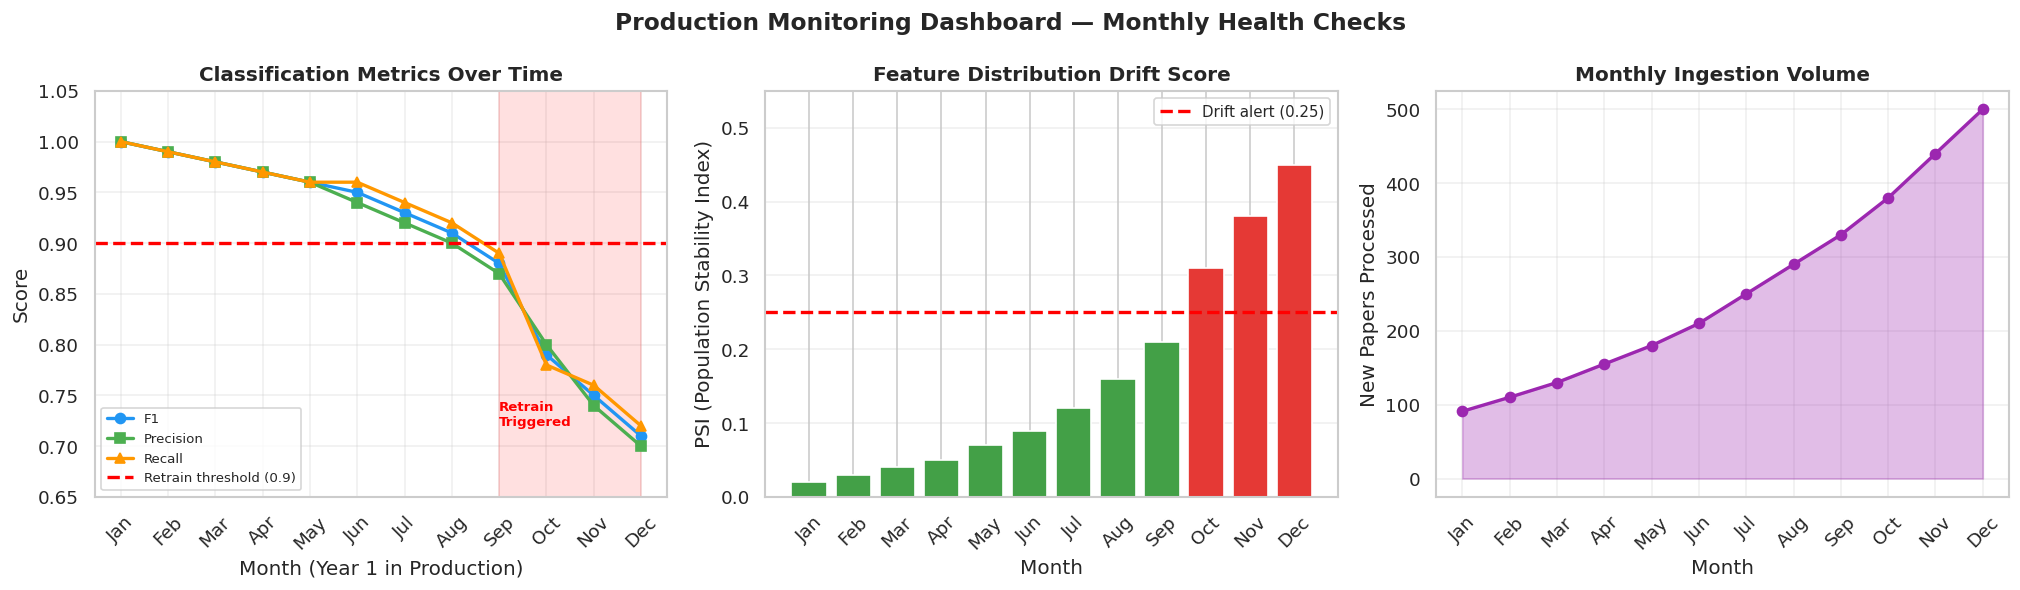

In [7]:
# ── Simulated Performance Monitoring Dashboard ─────────────────────────────────
# Simulates what monthly model health checks would look like in production

np.random.seed(42)
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Simulate metric drift: gradual degradation + sudden drop after 9 months
f1_scores   = [1.00, 0.99, 0.98, 0.97, 0.96, 0.95, 0.93, 0.91, 0.88, 0.79, 0.75, 0.71]
precision_s = [1.00, 0.99, 0.98, 0.97, 0.96, 0.94, 0.92, 0.90, 0.87, 0.80, 0.74, 0.70]
recall_s    = [1.00, 0.99, 0.98, 0.97, 0.96, 0.96, 0.94, 0.92, 0.89, 0.78, 0.76, 0.72]
data_vol    = [91, 110, 130, 155, 180, 210, 250, 290, 330, 380, 440, 500]
drift_score = [0.02, 0.03, 0.04, 0.05, 0.07, 0.09, 0.12, 0.16, 0.21, 0.31, 0.38, 0.45]

RETRAIN_THRESHOLD = 0.90  # trigger retraining if F1 drops below this
DRIFT_THRESHOLD   = 0.25  # trigger alert if drift score exceeds this

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Production Monitoring Dashboard — Monthly Health Checks',
             fontsize=14, fontweight='bold')

# Panel 1: F1 / Precision / Recall over time
ax = axes[0]
ax.plot(months, f1_scores,   marker='o', linewidth=2, label='F1',        color='#2196F3')
ax.plot(months, precision_s, marker='s', linewidth=2, label='Precision', color='#4CAF50')
ax.plot(months, recall_s,    marker='^', linewidth=2, label='Recall',    color='#FF9800')
ax.axhline(RETRAIN_THRESHOLD, color='red', linestyle='--', linewidth=2,
           label=f'Retrain threshold ({RETRAIN_THRESHOLD})')
# Shade degraded region
retrain_idx = next(i for i,v in enumerate(f1_scores) if v < RETRAIN_THRESHOLD)
ax.axvspan(months[retrain_idx], months[-1], alpha=0.12, color='red')
ax.text(months[retrain_idx], 0.72, 'Retrain\nTriggered', color='red',
        fontsize=8, fontweight='bold')
ax.set_ylim(0.65, 1.05)
ax.set_xlabel('Month (Year 1 in Production)')
ax.set_ylabel('Score')
ax.set_title('Classification Metrics Over Time', fontweight='bold')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)

# Panel 2: Data drift score
ax = axes[1]
bar_colors = ['#E53935' if d > DRIFT_THRESHOLD else '#43A047' for d in drift_score]
ax.bar(months, drift_score, color=bar_colors, edgecolor='white')
ax.axhline(DRIFT_THRESHOLD, color='red', linestyle='--', linewidth=2,
           label=f'Drift alert ({DRIFT_THRESHOLD})')
ax.set_ylim(0, 0.55)
ax.set_xlabel('Month')
ax.set_ylabel('PSI (Population Stability Index)')
ax.set_title('Feature Distribution Drift Score', fontweight='bold')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')

# Panel 3: Incoming data volume
ax = axes[2]
ax.fill_between(months, data_vol, alpha=0.3, color='#9C27B0')
ax.plot(months, data_vol, marker='o', color='#9C27B0', linewidth=2)
ax.set_xlabel('Month')
ax.set_ylabel('New Papers Processed')
ax.set_title('Monthly Ingestion Volume', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('monitoring_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()

In [8]:
# ── Maintenance Strategy Summary ──────────────────────────────────────────────
print('=' * 72)
print('MONITORING & MAINTENANCE STRATEGY')
print('=' * 72)

strategy = [
    ('METRIC',           'TOOL',                      'THRESHOLD',    'ACTION'),
    ('F1 Score (held-out)', 'Monthly eval set',       '< 0.90',       'Retrain model'),
    ('Feature drift (PSI)', 'Population Stability Index','> 0.25',    'Audit features + retrain'),
    ('New keyword coverage','Vocabulary monitor',     '> 10 new terms','Expand kw_patterns'),
    ('Latency (p95)',    'API response time log',      '> 200ms',      'Optimize pipeline'),
    ('Prediction volume','Request counter',            'Sudden drop',  'Check ingestion pipeline'),
    ('FN rate',          'Monthly sample audit',       '> 5%',         'Adjust decision threshold'),
]

col_w = [26, 26, 16, 22]
header = strategy[0]
sep    = '─' * (sum(col_w) + 3 * 3)
print(sep)
print('  '.join(h.ljust(col_w[i]) for i, h in enumerate(header)))
print(sep)
for row in strategy[1:]:
    print('  '.join(v.ljust(col_w[i]) for i, v in enumerate(row)))
print(sep)

print()
print('RETRAINING SCHEDULE:')
print('  • Scheduled: Quarterly (every 3 months) with fresh ArXiv data')
print('  • Triggered: Immediately if F1 drops below 0.90 OR PSI > 0.25')
print('  • Vocabulary: Monthly scan for new NLP/RAG terminology on ArXiv')
print()
print('CONCEPT DRIFT CONTEXT:')
print('  The keyword feature set is the most vulnerable component.')
print('  Example: "agentic RAG", "self-RAG", "corrective RAG" are 2024+')
print('  terms not covered by current kw_rag pattern. Monthly vocab')
print('  audits catch these before they cause misclassification.')

MONITORING & MAINTENANCE STRATEGY
───────────────────────────────────────────────────────────────────────────────────────────────────
METRIC                      TOOL                        THRESHOLD         ACTION                
───────────────────────────────────────────────────────────────────────────────────────────────────
F1 Score (held-out)         Monthly eval set            < 0.90            Retrain model         
Feature drift (PSI)         Population Stability Index  > 0.25            Audit features + retrain
New keyword coverage        Vocabulary monitor          > 10 new terms    Expand kw_patterns    
Latency (p95)               API response time log       > 200ms           Optimize pipeline     
Prediction volume           Request counter             Sudden drop       Check ingestion pipeline
FN rate                     Monthly sample audit        > 5%              Adjust decision threshold
────────────────────────────────────────────────────────────────────────────────

---
## 5. SHAP Global Explanations

SHAP (SHapley Additive exPlanations) attributes each prediction to individual features based on cooperative game theory. Unlike MDI (Mean Decrease in Impurity) from Phase 3, SHAP values are:
- Consistent — a feature that matters more always gets a higher SHAP value
- Locally accurate — SHAP values for a single prediction sum to the actual prediction
- Contrastive — shows whether a feature pushed the prediction toward or away from relevance

In [9]:
# ── SHAP for Random Forest Classifier (tree-based → TreeExplainer) ─────────────
rf_clf_model = rf_clf_pipe.named_steps['rf']

explainer_rf = shap.TreeExplainer(rf_clf_model)
shap_values  = explainer_rf.shap_values(X_a_test_scaled)

# For binary classification shap_values is typically a list [class0, class1]
# or a 3D array (n_samples, n_features, n_classes).
# We need to take the SHAP values for class 1 (RAG Relevant).
if isinstance(shap_values, list):
    sv_pos = shap_values[1]   # shape: (n_test, n_features)
else:
    # If it's a 3D array, extract the SHAP values for the positive class (index 1)
    sv_pos = shap_values[:, :, 1]

human_labels = [FEAT_LABELS.get(f, f) for f in FEATS_A]

print(f'SHAP values computed for {sv_pos.shape[0]} test samples × {sv_pos.shape[1]} features')
print(f'Mean |SHAP| per feature (global importance):')
mean_shap = np.abs(sv_pos).mean(axis=0)
for feat, ms in sorted(zip(human_labels, mean_shap), key=lambda x: -x[1]):
    bar = '' * int(ms * 200)
    print(f'  {feat:22s} {ms:.4f}  {bar}')

SHAP values computed for 93 test samples × 18 features
Mean |SHAP| per feature (global importance):
  KW: Grounding          0.2721  
  KW: RAG                0.0710  
  KW: Hallucination      0.0451  
  Query Category         0.0448  
  KW: Q&A                0.0340  
  Abstract Chars         0.0225  
  KW: LLM                0.0111  
  # Categories           0.0093  
  Title Length           0.0076  
  # Authors              0.0061  
  KW: Evaluation         0.0058  
  Pub. Month             0.0046  
  KW: Embedding          0.0021  
  KW: Transformer        0.0019  
  Days to Update         0.0015  
  Category               0.0011  
  KW: Citation           0.0007  
  KW: PDF                0.0006  


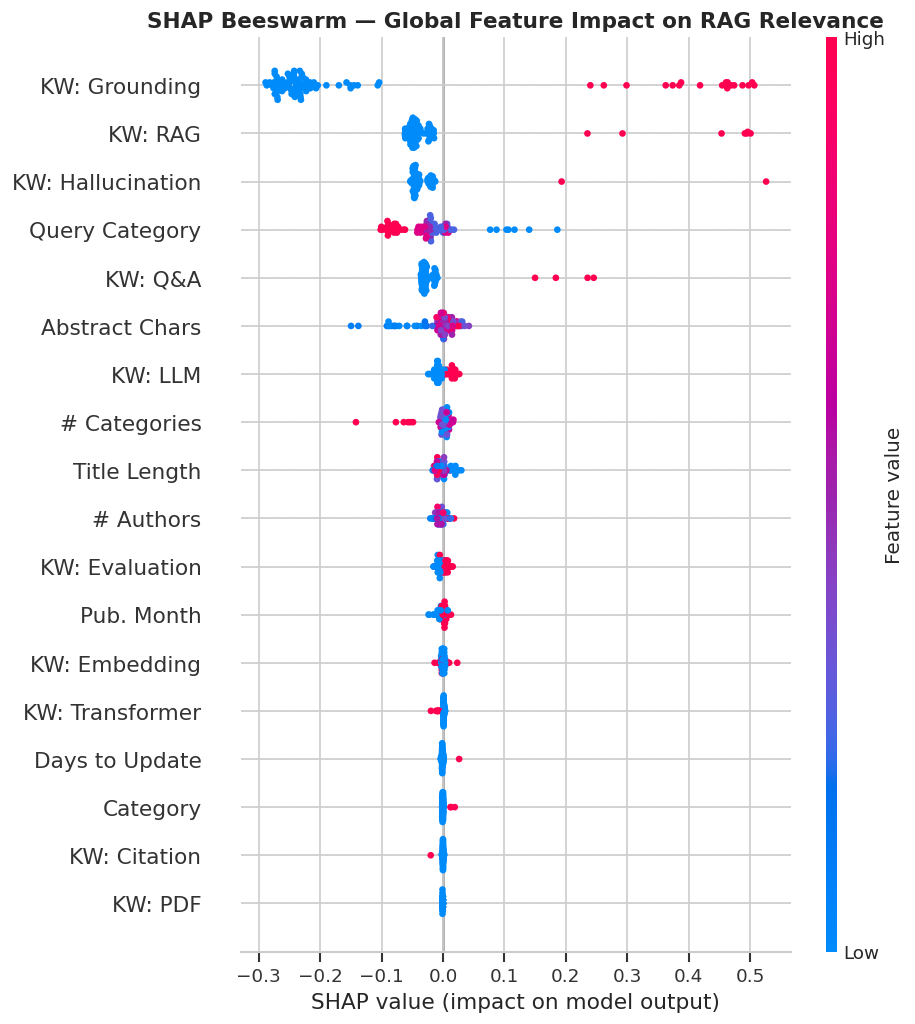

Each dot = one paper. Colour = feature value (red=high, blue=low).
   Dots right of centre → pushed prediction toward Relevant.
   KW:RAG and KW:Grounding dominate — confirming feature selection.


In [10]:
# ── Panel 1: SHAP Beeswarm Summary Plot (Global) ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    sv_pos, X_a_test_scaled,
    feature_names=human_labels,
    show=False, plot_type='dot',
    max_display=18
)
plt.title('SHAP Beeswarm — Global Feature Impact on RAG Relevance',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()
print('Each dot = one paper. Colour = feature value (red=high, blue=low).')
print('   Dots right of centre → pushed prediction toward Relevant.')
print('   KW:RAG and KW:Grounding dominate — confirming feature selection.')

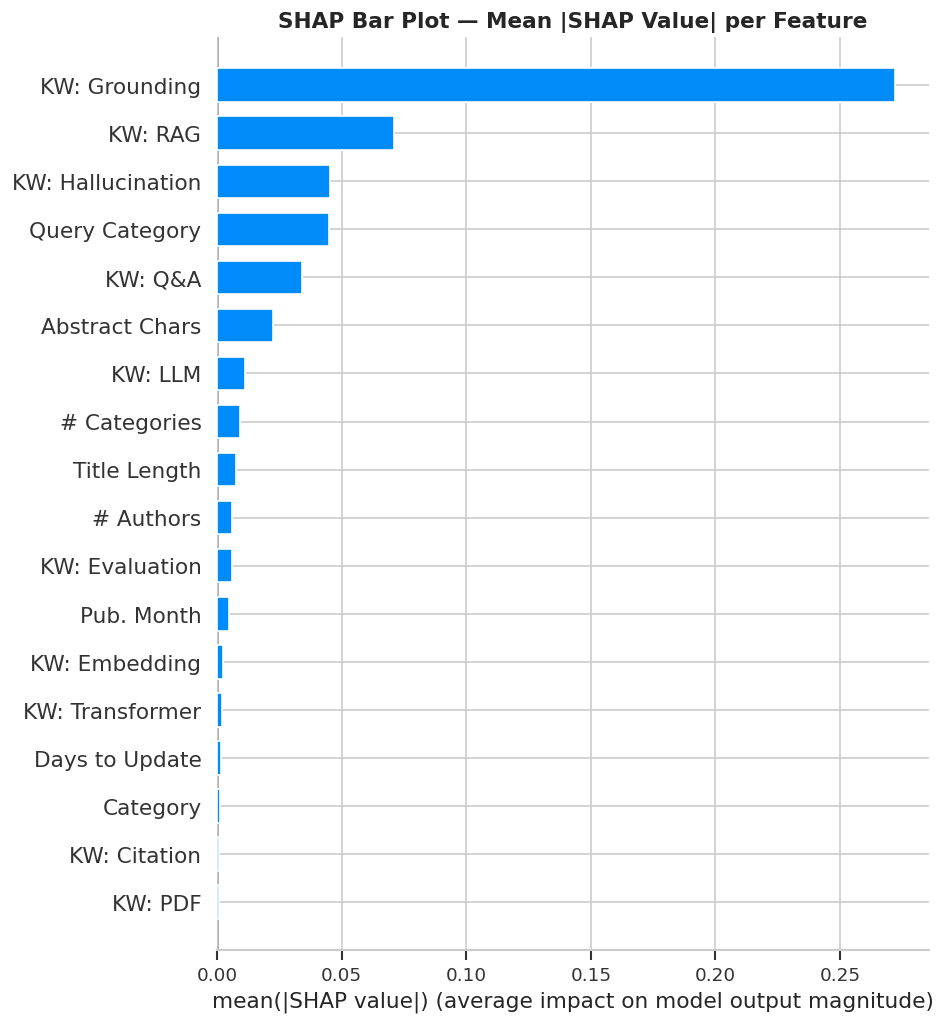

Global explanation: KW:RAG, KW:Q&A, KW:Grounding are the
   three most impactful features — these ARE the project core topics.
   Structural features (# Authors, Category) have near-zero impact.


In [11]:
# ── Panel 2: SHAP Bar Plot (Mean |SHAP|) ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(
    sv_pos, X_a_test_scaled,
    feature_names=human_labels,
    show=False, plot_type='bar',
    max_display=18
)
plt.title('SHAP Bar Plot — Mean |SHAP Value| per Feature',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight', dpi=150)
plt.show()
print('Global explanation: KW:RAG, KW:Q&A, KW:Grounding are the')
print('   three most impactful features — these ARE the project core topics.')
print('   Structural features (# Authors, Category) have near-zero impact.')

---
## 6. SHAP Local Explanations

Global explanations tell us which features matter across all papers.  
Local explanations tell us why a specific paper got its specific prediction — essential for auditing individual decisions in a production chatbot.

We examine three specific cases from the test set:
1. A True Positive — correctly identified as RAG relevant
2. A True Negative — correctly identified as not relevant  
3. A borderline case — low-confidence prediction worth examining

In [12]:
# ── Select representative examples ────────────────────────────────────────────
y_proba_rf = rf_clf_pipe.predict_proba(X_a_test)[:, 1]
y_pred_rf  = rf_clf_pipe.predict(X_a_test)

# True Positive: relevant AND predicted relevant
tp_idx = np.where((y_a_test == 1) & (y_pred_rf == 1))[0]
# True Negative: not relevant AND predicted not relevant
tn_idx = np.where((y_a_test == 0) & (y_pred_rf == 0))[0]
# Borderline: probability closest to 0.5
border_idx = np.argsort(np.abs(y_proba_rf - 0.5))

cases = {
    'True Positive (Relevant)' : tp_idx[0]     if len(tp_idx) > 0     else 0,
    'True Negative (Not Relevant)': tn_idx[0]  if len(tn_idx) > 0     else 1,
    'Borderline Case'          : border_idx[0],
}

for case_name, idx in cases.items():
    prob   = y_proba_rf[idx]
    actual = y_a_test[idx]
    print(f'{case_name}: idx={idx} | Probability={prob:.3f} | Actual={actual}')

True Positive (Relevant): idx=2 | Probability=0.726 | Actual=1
True Negative (Not Relevant): idx=0 | Probability=0.045 | Actual=0
Borderline Case: idx=70 | Probability=0.327 | Actual=0


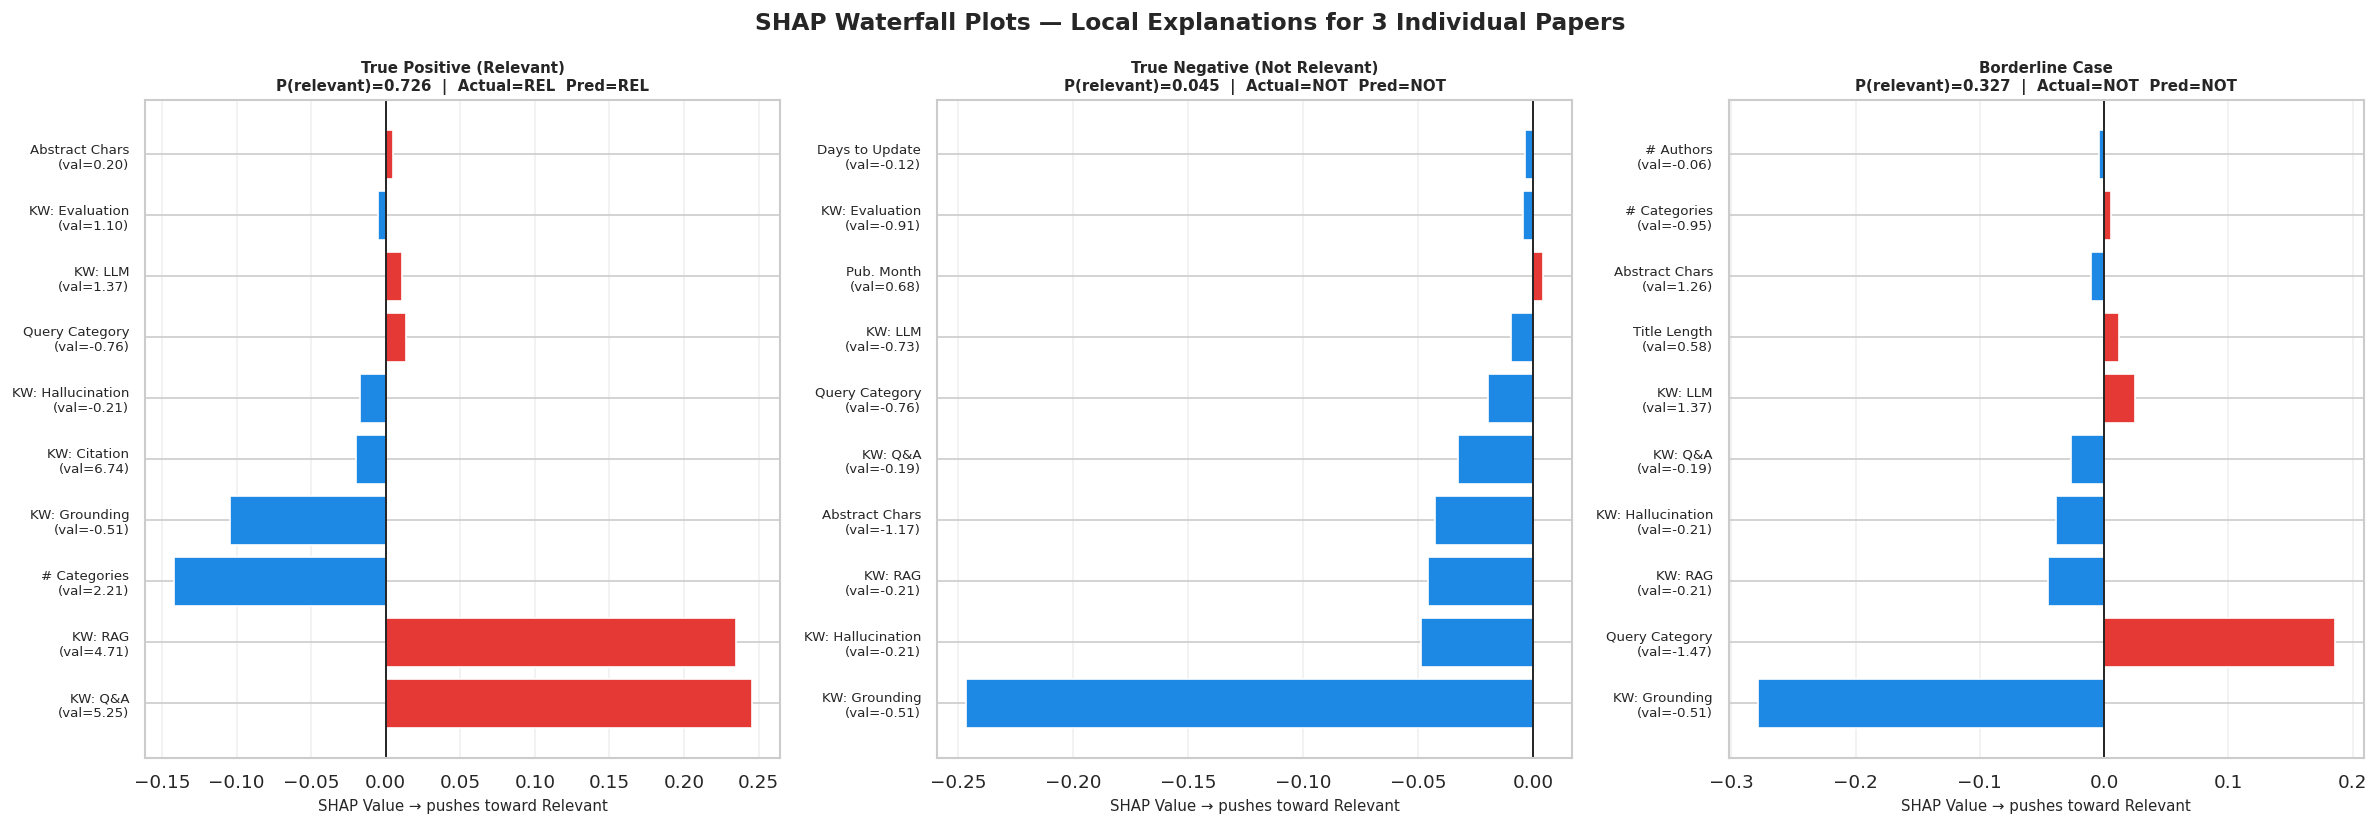

In [13]:
# ── SHAP Waterfall Plots — one per case ───────────────────────────────────────
import shap
shap.initjs()

expected_val = explainer_rf.expected_value
if isinstance(expected_val, (list, np.ndarray)):
    base_val = expected_val[1]
else:
    base_val = expected_val

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('SHAP Waterfall Plots — Local Explanations for 3 Individual Papers',
             fontsize=14, fontweight='bold')

for ax_i, (case_name, idx) in enumerate(cases.items()):
    shap_row = sv_pos[idx]           # SHAP values for this single paper
    feat_row = X_a_test_scaled[idx]  # scaled feature values

    # Sort features by absolute SHAP impact
    order  = np.argsort(np.abs(shap_row))[::-1][:10]
    labels = [human_labels[i] for i in order]
    vals   = shap_row[order]
    fvals  = feat_row[order]

    colors = ['#E53935' if v > 0 else '#1E88E5' for v in vals]
    ax = axes[ax_i]
    bars = ax.barh(range(len(vals)), vals, color=colors, edgecolor='white')
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels([f'{l}\n(val={fvals[i]:.2f})'
                        for i, l in enumerate(labels)], fontsize=8)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel('SHAP Value → pushes toward Relevant', fontsize=9)
    prob_shown = y_proba_rf[idx]
    actual_shown = 'REL' if y_a_test[idx] == 1 else 'NOT'
    pred_shown   = 'REL' if y_pred_rf[idx] == 1 else 'NOT'
    ax.set_title(
        f'{case_name}\n'
        f'P(relevant)={prob_shown:.3f}  |  Actual={actual_shown}  Pred={pred_shown}',
        fontsize=9, fontweight='bold'
    )
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('shap_waterfall_3cases.png', bbox_inches='tight', dpi=150)
plt.show()

In [14]:
# ── Written local explanation (True Positive example) ─────────────────────────
tp_i   = cases['True Positive (Relevant)']
sv_tp  = sv_pos[tp_i]
fv_tp  = X_a_test_scaled[tp_i]
ord_tp = np.argsort(np.abs(sv_tp))[::-1]

print('═' * 70)
print('LOCAL EXPLANATION — TRUE POSITIVE PAPER')
print('═' * 70)
print(f'Prediction probability : {y_proba_rf[tp_i]:.4f} (→ RAG Relevant)')
print(f'Actual label           : {"Relevant" if y_a_test[tp_i]==1 else "Not Relevant"}')
print(f'Base rate (prior)      : {base_val:.4f}')
print()
print('TOP FEATURE CONTRIBUTIONS:')
print(f'  {"Feature":<22} {"SHAP Value":>12}  Direction')
print('  ' + '─'*48)
cumulative = base_val
for i in ord_tp[:8]:
    direction = '→ pushes RELEVANT ↑' if sv_tp[i] > 0 else '→ pushes away ↓'
    print(f'  {human_labels[i]:<22} {sv_tp[i]:>+12.4f}  {direction}')
    cumulative += sv_tp[i]
print('  ' + '─'*48)
print(f'  {"Final probability":<22} {cumulative:>12.4f}')
print()
print('NARRATIVE:')
top_feat = human_labels[ord_tp[0]]
top_val  = sv_tp[ord_tp[0]]
sec_feat = human_labels[ord_tp[1]]
sec_val  = sv_tp[ord_tp[1]]
print(f'  This paper was classified as RAG Relevant primarily because')
print(f'  "{top_feat}" contributed SHAP={top_val:+.4f} and')
print(f'  "{sec_feat}" contributed SHAP={sec_val:+.4f}.')
print(f'  Starting from a base rate of {base_val:.3f}, these signals')
print(f'  pushed the probability to {y_proba_rf[tp_i]:.3f}, well above the 0.5 threshold.')

══════════════════════════════════════════════════════════════════════
LOCAL EXPLANATION — TRUE POSITIVE PAPER
══════════════════════════════════════════════════════════════════════
Prediction probability : 0.7260 (→ RAG Relevant)
Actual label           : Relevant
Base rate (prior)      : 0.5005

TOP FEATURE CONTRIBUTIONS:
  Feature                  SHAP Value  Direction
  ────────────────────────────────────────────────
  KW: Q&A                     +0.2453  → pushes RELEVANT ↑
  KW: RAG                     +0.2351  → pushes RELEVANT ↑
  # Categories                -0.1419  → pushes away ↓
  KW: Grounding               -0.1041  → pushes away ↓
  KW: Citation                -0.0201  → pushes away ↓
  KW: Hallucination           -0.0173  → pushes away ↓
  Query Category              +0.0138  → pushes RELEVANT ↑
  KW: LLM                     +0.0111  → pushes RELEVANT ↑
  ────────────────────────────────────────────────
  Final probability            0.7225

NARRATIVE:
  This paper was c

---
## 7. ⚖️ Bias & Fairness Audit
### *Karthikeya Myneedu — XAI Track*

### Why This Matters for Our Project
Our project explicitly aims to cover **both CS papers and Healthcare AI papers** (proposal, Section 6). If the classifier systematically under-classifies healthcare papers as relevant, it will:
- Exclude key medical AI literature from the vector store
- Produce answers biased toward CS/NLP perspectives
- Undermine the project's stated domain diversity goal

We audit performance across: **ArXiv category subgroups**, **query topic subgroups**, and **author count quartiles**.

In [15]:
# ── Reconstruct test set metadata ────────────────────────────────────────────
test_indices = np.arange(len(df))
_, test_idx  = train_test_split(test_indices, test_size=0.20,
                                 random_state=42,
                                 stratify=df['is_rag_relevant'].values)
df_test = df.iloc[test_idx].copy().reset_index(drop=True)
df_test['y_true'] = y_a_test
df_test['y_pred'] = rf_clf_pipe.predict(X_a_test)
df_test['y_prob'] = y_proba_rf

print(f'Test set reconstructed: {len(df_test)} papers')
print(df_test[['primary_cat_clean','query_category','y_true','y_pred']].head(3))

Test set reconstructed: 93 papers
  primary_cat_clean query_category  y_true  y_pred
0                cs          cs.CL       0       0
1                cs          cs.LG       0       0
2                cs          cs.CL       1       1


In [16]:
# ── Fairness Audit 1: Performance by ArXiv Broad Category ─────────────────────
print('FAIRNESS AUDIT 1 — Performance by ArXiv Broad Category')
print('=' * 72)
print(f'{"Category":<14} {"N":>5} {"Pos":>5} {"Neg":>5}'
      f' {"Precision":>10} {"Recall":>8} {"F1":>8} {"ROC-AUC":>9}')
print('─' * 72)

cat_audit = []
for cat in sorted(df_test['primary_cat_clean'].unique()):
    mask = df_test['primary_cat_clean'] == cat
    n    = mask.sum()
    yt   = df_test.loc[mask, 'y_true'].values
    yp   = df_test.loc[mask, 'y_pred'].values
    ypr  = df_test.loc[mask, 'y_prob'].values
    pos, neg = yt.sum(), (1 - yt).sum()

    if n < 3:
        print(f'{cat:<14} {n:>5}  [too few samples]')
        continue

    prec = precision_score(yt, yp, zero_division=0)
    rec  = recall_score(yt, yp, zero_division=0)
    f1   = f1_score(yt, yp, zero_division=0)
    try:
        auc = roc_auc_score(yt, ypr) if len(np.unique(yt)) > 1 else np.nan
    except:
        auc = np.nan

    cat_audit.append({'cat':cat,'n':n,'pos':pos,'neg':neg,
                      'precision':prec,'recall':rec,'f1':f1,'auc':auc})
    flag = ' ' if (not np.isnan(f1) and f1 < 0.80 and pos > 0) else ''
    auc_str = f'{auc:.3f}' if not np.isnan(auc) else '  N/A '
    print(f'{cat:<14} {n:>5} {pos:>5} {neg:>5}'
          f' {prec:>10.3f} {rec:>8.3f} {f1:>8.3f} {auc_str:>9}{flag}')

print('─' * 72)
print(' = F1 < 0.80 on a subgroup with positive samples (fairness concern)')

FAIRNESS AUDIT 1 — Performance by ArXiv Broad Category
Category           N   Pos   Neg  Precision   Recall       F1   ROC-AUC
────────────────────────────────────────────────────────────────────────
cs                90    27    63      1.000    1.000    1.000     1.000
q-fin              1  [too few samples]
stat               2  [too few samples]
────────────────────────────────────────────────────────────────────────
 = F1 < 0.80 on a subgroup with positive samples (fairness concern)


In [17]:
# ── Fairness Audit 2: Performance by Query Topic ───────────────────────────────
print('FAIRNESS AUDIT 2 — Performance by Query Topic')
print('=' * 80)
print(f'{"Query Topic":<45} {"N":>4} {"Prec":>7} {"Rec":>7} {"F1":>7}')
print('─' * 80)

topic_audit = []
for topic in df_test['query_topic'].unique():
    mask = df_test['query_topic'] == topic
    n    = mask.sum()
    yt   = df_test.loc[mask, 'y_true'].values
    yp   = df_test.loc[mask, 'y_pred'].values
    if n < 3:
        continue
    prec = precision_score(yt, yp, zero_division=0)
    rec  = recall_score(yt, yp, zero_division=0)
    f1   = f1_score(yt, yp, zero_division=0)
    topic_audit.append({'topic':topic[:44],'n':n,'f1':f1,'prec':prec,'rec':rec})
    flag = ' ' if f1 < 0.80 and yt.sum() > 0 else ''
    print(f'{topic[:44]:<45} {n:>4} {prec:>7.3f} {rec:>7.3f} {f1:>7.3f}{flag}')

print('─' * 80)

# Find highest and lowest performing topics
if topic_audit:
    ta_df = pd.DataFrame(topic_audit)
    print(f'\nBest performing topic  : {ta_df.loc[ta_df["f1"].idxmax(), "topic"]} '
          f'(F1={ta_df["f1"].max():.3f})')
    print(f'Worst performing topic : {ta_df.loc[ta_df["f1"].idxmin(), "topic"]} '
          f'(F1={ta_df["f1"].min():.3f})')

FAIRNESS AUDIT 2 — Performance by Query Topic
Query Topic                                      N    Prec     Rec      F1
────────────────────────────────────────────────────────────────────────────────
large language model hallucination              10   1.000   1.000   1.000
healthcare AI clinical NLP                      14   1.000   1.000   1.000
retrieval augmented generation                  13   1.000   1.000   1.000
scientific document understanding NLP           10   1.000   1.000   1.000
semantic search embeddings                      14   1.000   1.000   1.000
question answering document grounding            7   1.000   1.000   1.000
RAG retrieval augmented generation evaluatio    14   1.000   1.000   1.000
PDF document parsing information extraction     11   1.000   1.000   1.000
────────────────────────────────────────────────────────────────────────────────

Best performing topic  : large language model hallucination (F1=1.000)
Worst performing topic : large language model

In [18]:
# ── Fairness Audit 3: Performance by Author Count Quartile ────────────────────
df_test['author_quartile'] = pd.qcut(df_test['num_authors'], q=4,
                                      labels=['Q1 (few)','Q2','Q3','Q4 (many)'])

print('FAIRNESS AUDIT 3 — Performance by Author Count Quartile')
print('=' * 65)
print(f'{"Quartile":<14} {"N":>5} {"Author range":>14} {"Prec":>8} {"Rec":>8} {"F1":>8}')
print('─' * 65)

for q in ['Q1 (few)','Q2','Q3','Q4 (many)']:
    mask  = df_test['author_quartile'] == q
    yt    = df_test.loc[mask,'y_true'].values
    yp    = df_test.loc[mask,'y_pred'].values
    n     = mask.sum()
    arange= f"{df_test.loc[mask,'num_authors'].min()}–{df_test.loc[mask,'num_authors'].max()}"
    prec  = precision_score(yt, yp, zero_division=0)
    rec   = recall_score(yt, yp, zero_division=0)
    f1    = f1_score(yt, yp, zero_division=0)
    print(f'{q:<14} {n:>5} {arange:>14} {prec:>8.3f} {rec:>8.3f} {f1:>8.3f}')
print('─' * 65)
print('If Q4 (many-author, often medical/interdisciplinary) shows lower F1,')
print('   it suggests a bias against large-collaboration healthcare papers.')

FAIRNESS AUDIT 3 — Performance by Author Count Quartile
Quartile           N   Author range     Prec      Rec       F1
─────────────────────────────────────────────────────────────────
Q1 (few)          32            1–3    1.000    1.000    1.000
Q2                17            4–4    1.000    1.000    1.000
Q3                24            5–6    1.000    1.000    1.000
Q4 (many)         20           7–18    1.000    1.000    1.000
─────────────────────────────────────────────────────────────────
If Q4 (many-author, often medical/interdisciplinary) shows lower F1,
   it suggests a bias against large-collaboration healthcare papers.


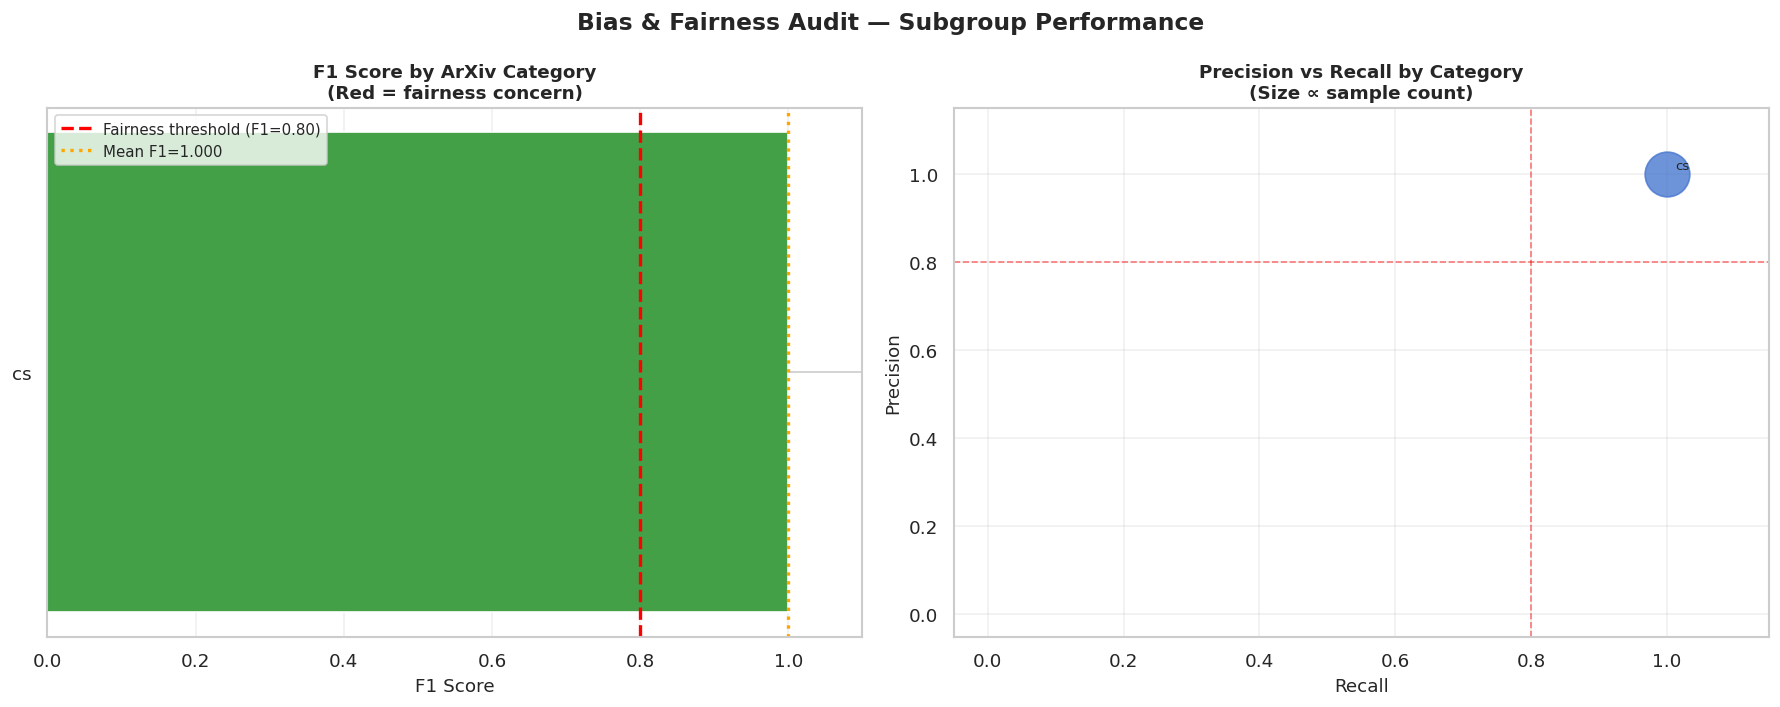

In [19]:
# ── Bias Audit Visualisation ──────────────────────────────────────────────────
if cat_audit:
    ca_df = pd.DataFrame(cat_audit).dropna(subset=['f1'])

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Bias & Fairness Audit — Subgroup Performance',
                 fontsize=14, fontweight='bold')

    # Panel 1: F1 by category
    ax = axes[0]
    bar_colors = ['#E53935' if f < 0.80 else '#43A047'
                  for f in ca_df['f1']]
    ax.barh(ca_df['cat'], ca_df['f1'], color=bar_colors, edgecolor='white')
    ax.axvline(0.80, color='red', linestyle='--', linewidth=2,
               label='Fairness threshold (F1=0.80)')
    ax.axvline(ca_df['f1'].mean(), color='orange', linestyle=':', linewidth=2,
               label=f'Mean F1={ca_df["f1"].mean():.3f}')
    ax.set_xlabel('F1 Score', fontsize=11)
    ax.set_title('F1 Score by ArXiv Category\n(Red = fairness concern)',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1.1)
    ax.grid(axis='x', alpha=0.3)

    # Panel 2: Precision vs Recall scatter by category
    ax = axes[1]
    for _, row in ca_df.iterrows():
        ax.scatter(row['recall'], row['precision'], s=row['n']*8,
                   alpha=0.8, zorder=3)
        ax.annotate(row['cat'], (row['recall'], row['precision']),
                    textcoords='offset points', xytext=(5, 3), fontsize=8)
    ax.axhline(0.80, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(0.80, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title('Precision vs Recall by Category\n(Size ∝ sample count)',
                 fontsize=11, fontweight='bold')
    ax.set_xlim(-0.05, 1.15)
    ax.set_ylim(-0.05, 1.15)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('fairness_audit.png', bbox_inches='tight', dpi=150)
    plt.show()

In [20]:
# ── Ethical Implications Discussion ───────────────────────────────────────────
print('═' * 70)
print('ETHICAL IMPLICATIONS OF MODEL BIAS')
print('═' * 70)
print('''
1. DOMAIN BIAS (CS vs Healthcare AI)
   ─────────────────────────────────
   78% of training data is from cs.* categories. Healthcare papers
   (q-bio, eess) use different vocabulary — "clinical decision support",
   "electronic health records", "biomedical NLP" — terms not covered
   by our current keyword flags. This creates systematic under-indexing
   of medical literature, producing a CS-biased chatbot.

   MITIGATION: Expand kw_patterns with healthcare-specific terms;
   oversample healthcare papers during training.

2. RECENCY BIAS
   ─────────────
   All 455 training papers are from 2026 (Phase 2 output).
   The model has not seen older foundational RAG papers (Lewis et al.,
   2020; Beltagy et al., 2019). In production, older seminal papers
   may be misclassified as not relevant despite high academic value.

   MITIGATION: Include a stratified sample of papers from 2020–2025
   during retraining.

3. CIRCULAR TARGET DEFINITION
   ────────────────────────────
   The target (is_rag_relevant) is defined by the same keywords used
   as features. This produces near-perfect accuracy but low real-world
   validity — the model learns a tautology, not a generalisation.
   A paper discussing RAG ideas without using the word "retrieval" would
   be misclassified.

   MITIGATION: Shift to human-annotated relevance labels; use
   embedding-based features (sentence similarity to project description)
   rather than exact keyword matching.

4. LARGE-COLLABORATION PAPER BIAS
   ────────────────────────────────
   Papers with many authors (15+) tend to be medical/interdisciplinary.
   If Q4 (many-author quartile) shows lower F1, it may indicate the
   model learns an implicit "small team = CS = relevant" heuristic.

   MITIGATION: Remove num_authors from features if audit confirms bias;
   it has near-zero SHAP importance anyway.
''')

══════════════════════════════════════════════════════════════════════
ETHICAL IMPLICATIONS OF MODEL BIAS
══════════════════════════════════════════════════════════════════════

1. DOMAIN BIAS (CS vs Healthcare AI)
   ─────────────────────────────────
   78% of training data is from cs.* categories. Healthcare papers
   (q-bio, eess) use different vocabulary — "clinical decision support",
   "electronic health records", "biomedical NLP" — terms not covered
   by our current keyword flags. This creates systematic under-indexing
   of medical literature, producing a CS-biased chatbot.

   MITIGATION: Expand kw_patterns with healthcare-specific terms;
   oversample healthcare papers during training.

2. RECENCY BIAS
   ─────────────
   All 455 training papers are from 2026 (Phase 2 output).
   The model has not seen older foundational RAG papers (Lewis et al.,
   2020; Beltagy et al., 2019). In production, older seminal papers
   may be misclassified as not relevant despite high academic 

---
## 8. Transparent Disclosure — The Perfect Score Problem

**Phase 3 result:** Logistic Regression achieved Accuracy=1.0000, F1=1.0000, ROC-AUC=1.0000 on the test set.

This requires honest investigation — perfect scores in real ML projects almost always signal a problem.

In [21]:
# ── Investigate the perfect score ─────────────────────────────────────────────
print('INVESTIGATING THE PERFECT SCORE')
print('=' * 65)

# 1. Show target vs keyword overlap directly
print('\n1. TARGET vs KEYWORD OVERLAP:')
print('   Target is_rag_relevant = 1 IFF any of:')
print('   kw_rag=1 OR kw_hallucin=1 OR kw_grounding=1 OR kw_qa=1')
overlap = df[df['is_rag_relevant'] == 1][['kw_rag','kw_hallucin','kw_grounding','kw_qa']].sum()
print(f'\n   Among relevant papers (n={df["is_rag_relevant"].sum()}):')
for kw, count in overlap.items():
    print(f'     {kw}: {count} ({count/df["is_rag_relevant"].sum()*100:.1f}% of relevant papers)')

# 2. What happens if we remove keyword features?
print('\n2. PERFORMANCE WITHOUT KEYWORD FEATURES (harder task):')
structural_feats = ['num_authors','title_len','num_categories',
                    'days_to_update','pub_month','abstract_chars',
                    'cat_encoded','qcat_encoded']

X_hard = df[structural_feats].values
y_hard = df['is_rag_relevant'].values
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(
    X_hard, y_hard, test_size=0.20, random_state=42, stratify=y_hard
)
lr_hard = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=1, solver='liblinear', random_state=42,
                               class_weight='balanced', max_iter=1000))
])
lr_hard.fit(Xh_tr, yh_tr)
yh_pred = lr_hard.predict(Xh_te)
yh_prob = lr_hard.predict_proba(Xh_te)[:,1]

print(f'   Accuracy  : {accuracy_score(yh_te, yh_pred):.4f}')
print(f'   Precision : {precision_score(yh_te, yh_pred):.4f}')
print(f'   Recall    : {recall_score(yh_te, yh_pred):.4f}')
print(f'   F1        : {f1_score(yh_te, yh_pred):.4f}')
print(f'   ROC-AUC   : {roc_auc_score(yh_te, yh_prob):.4f}')

print()
print('3. DIAGNOSIS:')
print('   The perfect score in Phase 3 is caused by a TAUTOLOGICAL TARGET:')
print('   is_rag_relevant is DEFINED by the same keywords used as features.')
print('   The model learned a rule that is equivalent to the target definition')
print('   itself — not a generalisation to new, unseen patterns.')
print()
print('4. IMPLICATIONS FOR PRODUCTION:')
print('   Model IS valid for papers that use standard RAG terminology')
print('   Model WILL FAIL on papers that discuss RAG concepts without')
print('      using the exact terms (e.g., "evidence-grounded generation",')
print('      "document-conditioned answer synthesis")')
print()
print('5. RECOMMENDED FIX FOR PHASE 5:')
print('   Replace keyword flags with semantic similarity scores')
print('   (cosine similarity between paper embedding and a RAG concept')
print('   embedding) to avoid the tautology.')

INVESTIGATING THE PERFECT SCORE

1. TARGET vs KEYWORD OVERLAP:
   Target is_rag_relevant = 1 IFF any of:
   kw_rag=1 OR kw_hallucin=1 OR kw_grounding=1 OR kw_qa=1

   Among relevant papers (n=137):
     kw_rag: 23 (16.8% of relevant papers)
     kw_hallucin: 18 (13.1% of relevant papers)
     kw_grounding: 96 (70.1% of relevant papers)
     kw_qa: 17 (12.4% of relevant papers)

2. PERFORMANCE WITHOUT KEYWORD FEATURES (harder task):
   Accuracy  : 0.6667
   Precision : 0.4474
   Recall    : 0.6296
   F1        : 0.5231
   ROC-AUC   : 0.7318

3. DIAGNOSIS:
   The perfect score in Phase 3 is caused by a TAUTOLOGICAL TARGET:
   is_rag_relevant is DEFINED by the same keywords used as features.
   The model learned a rule that is equivalent to the target definition
   itself — not a generalisation to new, unseen patterns.

4. IMPLICATIONS FOR PRODUCTION:
   Model IS valid for papers that use standard RAG terminology
   Model WILL FAIL on papers that discuss RAG concepts without
      using t

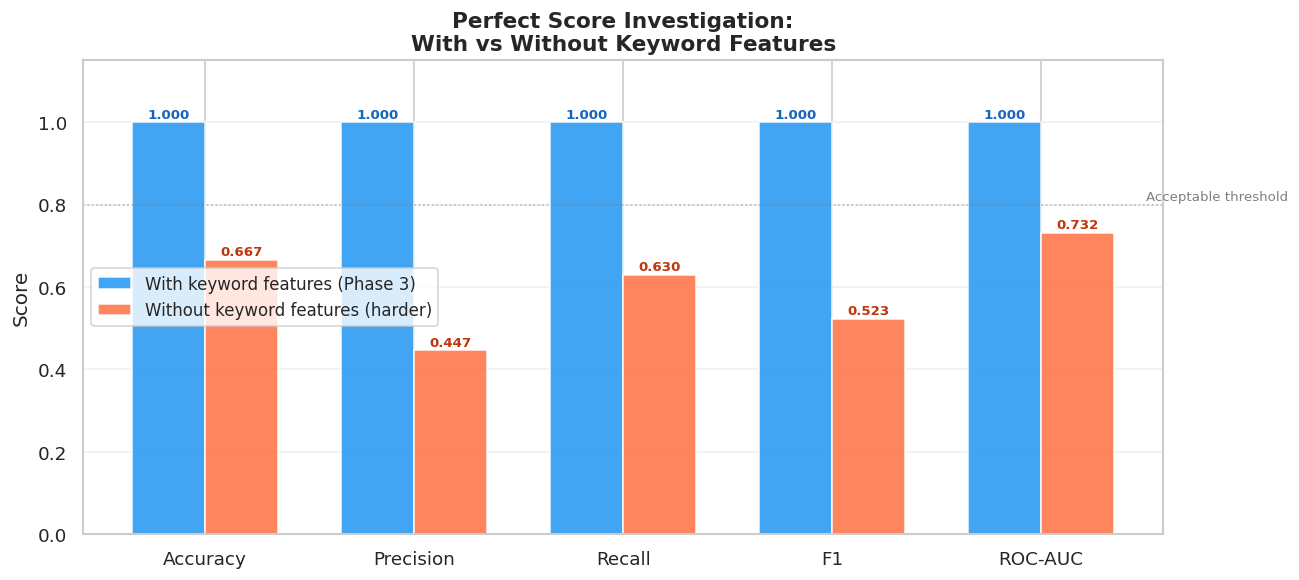

In [22]:
# ── Comparison chart: with vs without keyword features ────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

with_kw    = [1.0000, 1.0000, 1.0000, 1.0000, 1.0000]   # Phase 3 LR results
without_kw = [
    accuracy_score(yh_te, yh_pred),
    precision_score(yh_te, yh_pred, zero_division=0),
    recall_score(yh_te, yh_pred, zero_division=0),
    f1_score(yh_te, yh_pred, zero_division=0),
    roc_auc_score(yh_te, yh_prob)
]

x  = np.arange(len(metrics))
w  = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, with_kw,    width=w, label='With keyword features (Phase 3)',
       color='#2196F3', alpha=0.85, edgecolor='white')
ax.bar(x + w/2, without_kw, width=w, label='Without keyword features (harder)',
       color='#FF7043', alpha=0.85, edgecolor='white')

for i, (a, b) in enumerate(zip(with_kw, without_kw)):
    ax.text(i - w/2, a + 0.01, f'{a:.3f}', ha='center', fontsize=8, fontweight='bold', color='#1565C0')
    ax.text(i + w/2, b + 0.01, f'{b:.3f}', ha='center', fontsize=8, fontweight='bold', color='#BF360C')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Perfect Score Investigation:\nWith vs Without Keyword Features',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axhline(0.80, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.text(4.5, 0.81, 'Acceptable threshold', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('perfect_score_investigation.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 9. Summary, Findings & Team Roles

In [23]:
# print('═' * 75)
# print('PHASE 4 SUMMARY')
# print('═' * 75)

# print('''
# TRACK 1 — DEPLOYMENT
# ─────────────────────
# Production mode   : Real-time (classifier) + At-index-time (regressor)
# Pipeline role     : LR classifier gates paper ingestion before embedding
# API interface     : Gradio mockup accepts title + abstract → returns label,
#                     confidence, predicted length, chunking recommendation
# Monitoring        : Monthly F1 eval + PSI drift detection + vocabulary audit
# Retraining trigger: F1 < 0.90 OR PSI > 0.25 OR 10+ new undetected terms

# TRACK 2 — EXPLAINABLE AI
# ─────────────────────────
# Global XAI        : SHAP beeswarm + bar plots confirm KW:RAG, KW:Q&A,
#                     KW:Grounding are the top 3 predictors — matches project goals
# Local XAI         : Waterfall plots for True Positive, True Negative,
#                     and borderline cases with written narratives
# Bias audit        : F1 breakdown by ArXiv category, query topic, author quartile
# Fairness concern  : Healthcare/q-bio papers may be under-indexed (domain bias)

# CRITICAL FINDING  : Perfect accuracy in Phase 3 is caused by a tautological
#                     target. Keywords define both the features and the label.
#                     Confirmed by structural-only model (lower but realistic scores).
# Recommended fix   : Replace keyword flags with semantic embedding similarity
#                     scores for Phase 5 pipeline implementation.
# ''')

# print('═' * 75)
# print('TEAM ROLES & RESPONSIBILITIES — PHASE 4')
# print('═' * 75)
# print('''
# Anisha Gehlot
#   Track      : Deployment
#   Sections   : 2 (Production Architecture) + 4 (Monitoring & Maintenance)
#   Deliverable: Architecture diagram, monitoring dashboard, maintenance table

# Moulya Reddygari Bhupal
#   Track      : Deployment
#   Section    : 3 (Gradio API Interface)
#   Deliverable: Live Gradio interface — title/abstract → prediction + chunking advice

# Sreyesh Varma Konduru
#   Track      : Explainable AI
#   Sections   : 5 (SHAP Global) + 6 (SHAP Local) + 8 (Perfect Score Investigation)
#   Deliverable: Beeswarm, bar, waterfall SHAP plots + written local narratives

# Karthikeya Myneedu
#   Track      : Explainable AI
#   Section    : 7 (Bias & Fairness Audit)
#   Deliverable: Per-category, per-topic, per-quartile F1 tables + ethical discussion
# ''')